In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!ls "/content/drive/MyDrive/SkillCraft Internship"

'archive (1).zip'


In [16]:
!unzip -q "/content/drive/MyDrive/SkillCraft Internship/archive (1).zip" -d /content/

In [17]:
dataset_path = "/content/PetImages"

In [18]:
categories = ["Cat", "Dog"]
IMG_SIZE = 64
data = []
labels = []
MAX_IMAGES = 1000
for category in categories:
    folder = os.path.join(dataset_path, category)
    label = categories.index(category)
    count = 0
    for file in os.listdir(folder):
        if count >= MAX_IMAGES:
            break
        try:
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img.flatten())
            labels.append(label)
            count += 1
        except:
            pass
print("Total Images Loaded:", len(data))

Total Images Loaded: 2000


In [19]:
X = np.array(data)
y = np.array(labels)
print(X.shape)
print(y.shape)

(2000, 4096)
(2000,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [22]:
y_pred = model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.53


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.54      0.53       199
           1       0.53      0.52      0.53       201

    accuracy                           0.53       400
   macro avg       0.53      0.53      0.53       400
weighted avg       0.53      0.53      0.53       400



In [25]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[108  91]
 [ 97 104]]


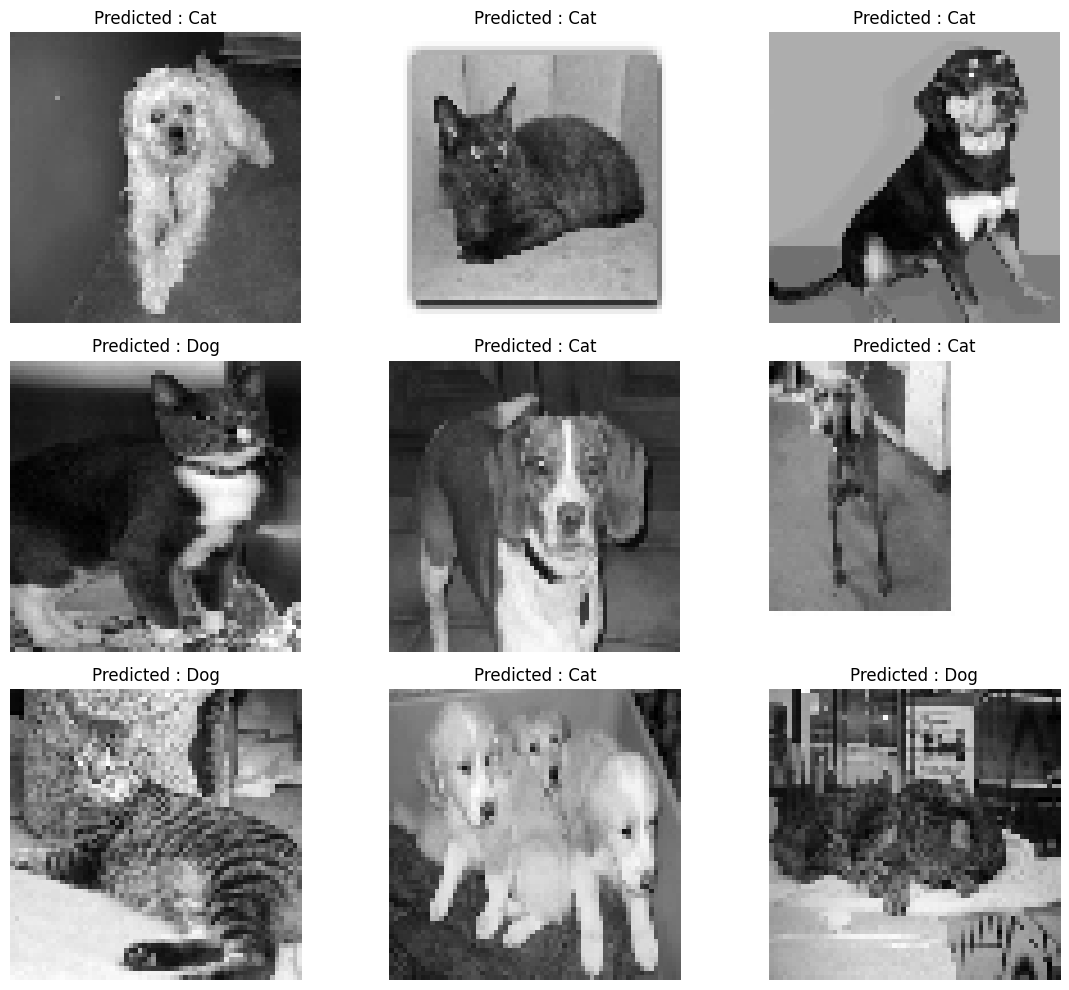

In [26]:
plt.figure(figsize=(12,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].reshape(64,64), cmap='gray')
    if y_pred[i] == 0:
        plt.title("Predicted : Cat")
    else:
        plt.title("Predicted : Dog")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [29]:
image_path = "/content/PetImages/Cat/1424.jpg" # Change to your uploaded image name

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found. Check the file name and path.")
else:
    img = cv2.resize(img, (64, 64))
    img = img.flatten().reshape(1, -1)

    prediction = model.predict(img)

    if prediction[0] == 0:
        print("Prediction: Cat")
    else:
        print("Prediction: Dog")

Prediction: Cat


In [38]:
from google.colab import files
uploaded = files.upload()
image_path = next(iter(uploaded))
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Unable to read the uploaded image.")
else:
    img = cv2.resize(img, (64, 64))
    img = img.flatten().reshape(1, -1)
    prediction = model.predict(img)
    if prediction[0] == 0:
        print("Prediction: Cat ")
    else:
        print("Prediction: Dog ")

Saving 38.jpg to 38.jpg
Prediction: Cat 
